In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
BLUE   = '#1F77B4'
ORANGE = '#FF7F0E'
RED    = '#D62728'
GREEN  = '#2CA02C'
PALETTE = sns.color_palette('Blues_d', 10)


In [2]:
df = pd.read_csv('combined_dataset.csv', low_memory=False)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Fix dep_hour / arvl_hour (stored as full timestamps, extract just the hour integer)
df['dep_hour_int']  = pd.to_datetime(df['dep_hour'],  errors='coerce').dt.hour
df['arvl_hour_int'] = pd.to_datetime(df['arvl_hour'], errors='coerce').dt.hour

# Parse scheduled departure for time-based features
df['dep_dt']    = pd.to_datetime(df['SCHD_LEG_DEP_LCL_TMS'], errors='coerce')
df['dep_dow']   = df['dep_dt'].dt.dayofweek
df['dep_month'] = df['dep_dt'].dt.month
df['dep_year']  = df['dep_dt'].dt.year

TARGET_DEP = 'LEG_DEP_VARNCE_MIN_QTY'
TARGET_ARV = 'LEG_ARVL_VARNCE_MIN_QTY'

Shape: 2,062,951 rows × 48 columns


---
## 1. Post-Join Data Health Check

In [3]:
# ── Raw vs combined row count ────────────────────────────────────────────────
raw_rows    = 2_259_582   # from ETA_clean
combined    = len(df)
dropped     = raw_rows - combined

print(f'Rows in ETA_clean (input) : {raw_rows:>12,}')
print(f'Rows in combined (output) : {combined:>12,}')
print(f'Rows dropped in join      : {dropped:>12,}  ({dropped/raw_rows*100:.1f}%)')
print()

# ── Missing after join ───────────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(miss_df)

Rows in ETA_clean (input) :    2,259,582
Rows in combined (output) :    2,062,951
Rows dropped in join      :      196,631  (8.7%)



,Missing Count,Missing %
dep_wxcodes,1803192,87.4
arvl_wxcodes,1802076,87.4
FLIFO_DELAY_REASON_CD,1019081,49.4
arvl_precipitation,141274,6.8
arvl_wind_speed,140495,6.8
arvl_visibility,140152,6.8
dep_precipitation,3904,0.2
dep_wind_speed,2319,0.1
dep_visibility,2213,0.1
OP_PRE_STATUS_CD,325,0.0


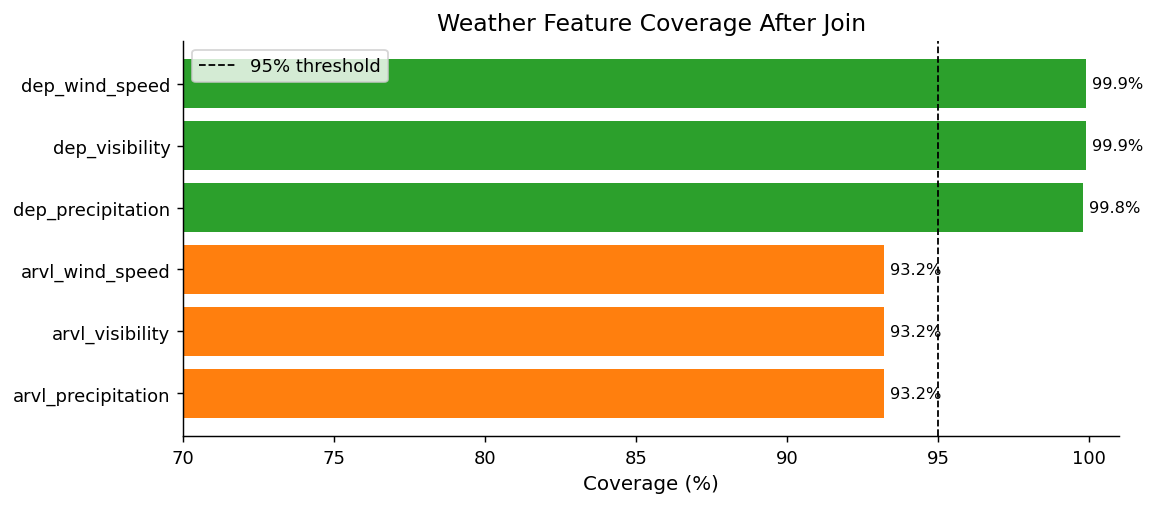

In [4]:
# ── Weather feature coverage ─────────────────────────────────────────────────
weather_cols = ['dep_wind_speed','dep_visibility','dep_precipitation',
                'arvl_wind_speed','arvl_visibility','arvl_precipitation']

coverage = pd.DataFrame({
    'Feature': weather_cols,
    'Coverage %': [(df[c].notna().mean()*100).round(1) for c in weather_cols],
    'Missing Count': [df[c].isna().sum() for c in weather_cols]
})

fig, ax = plt.subplots(figsize=(9, 4))
colors_cov = [GREEN if v > 95 else ORANGE if v > 85 else RED for v in coverage['Coverage %']]
ax.barh(coverage['Feature'][::-1], coverage['Coverage %'][::-1], color=colors_cov[::-1])
ax.axvline(95, color='black', linestyle='--', linewidth=1, label='95% threshold')
ax.set_xlabel('Coverage (%)')
ax.set_title('Weather Feature Coverage After Join')
ax.legend()
ax.set_xlim(70, 101)
for i, (pct, cnt) in enumerate(zip(coverage['Coverage %'][::-1], coverage['Missing Count'][::-1])):
    ax.text(pct + 0.2, i, f'{pct}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_comb_weather_coverage.png', bbox_inches='tight')
plt.show()

---
## 2. Target Variable Distributions (Combined Dataset)

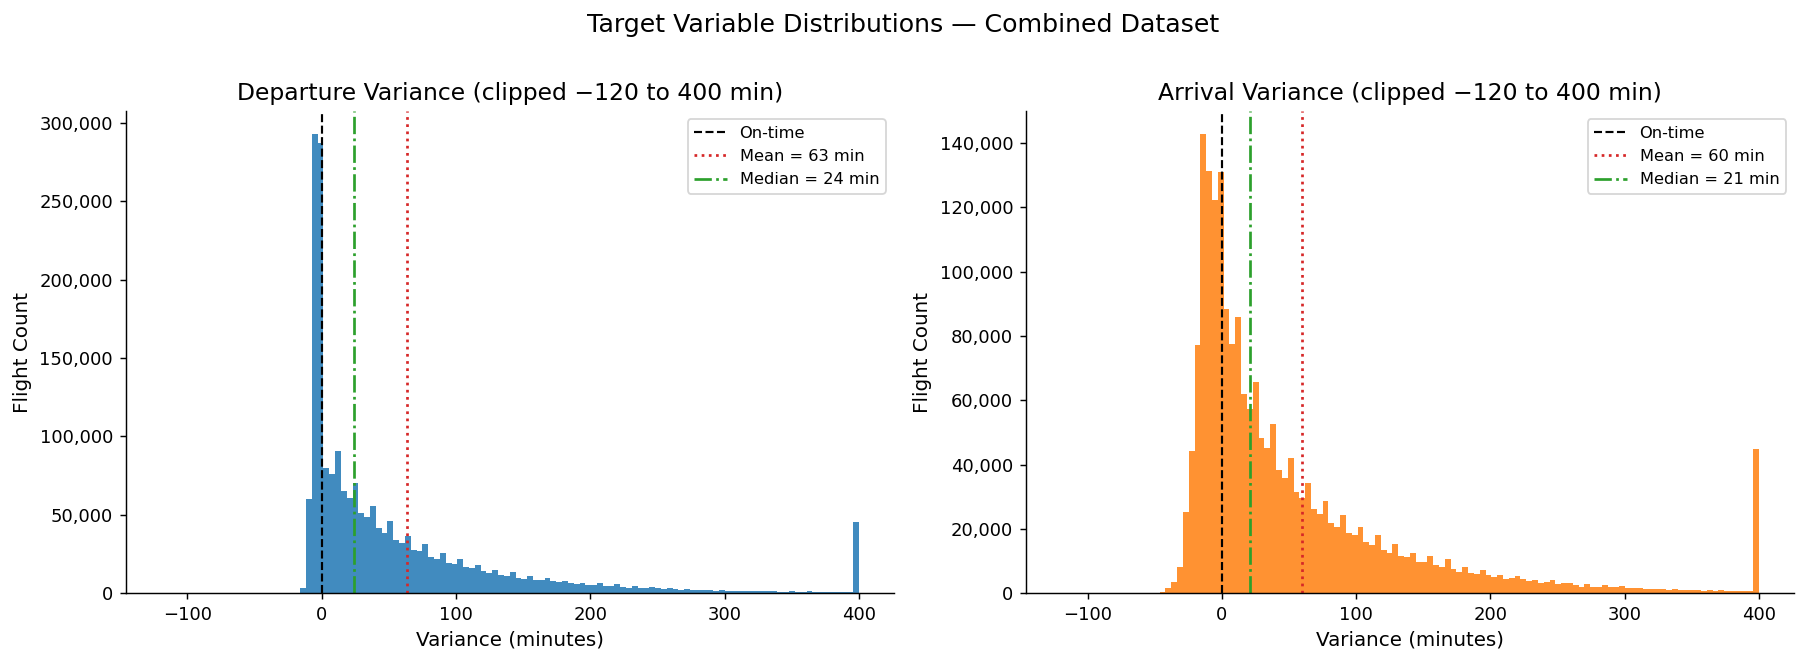

In [5]:
dep_var = df[TARGET_DEP].dropna()
arv_var = df[TARGET_ARV].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, color in zip(
    axes, [dep_var, arv_var],
    ['Departure Variance', 'Arrival Variance'],
    [BLUE, ORANGE]
):
    ax.hist(data.clip(-120, 400), bins=120, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(0,            color='black', linestyle='--', lw=1.2, label='On-time')
    ax.axvline(data.mean(),  color=RED,     linestyle=':',  lw=1.5, label=f'Mean = {data.mean():.0f} min')
    ax.axvline(data.median(),color=GREEN,   linestyle='-.',  lw=1.5, label=f'Median = {data.median():.0f} min')
    ax.set_xlabel('Variance (minutes)')
    ax.set_ylabel('Flight Count')
    ax.set_title(f'{label} (clipped −120 to 400 min)')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Target Variable Distributions — Combined Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_comb_targets.png', bbox_inches='tight')
plt.show()

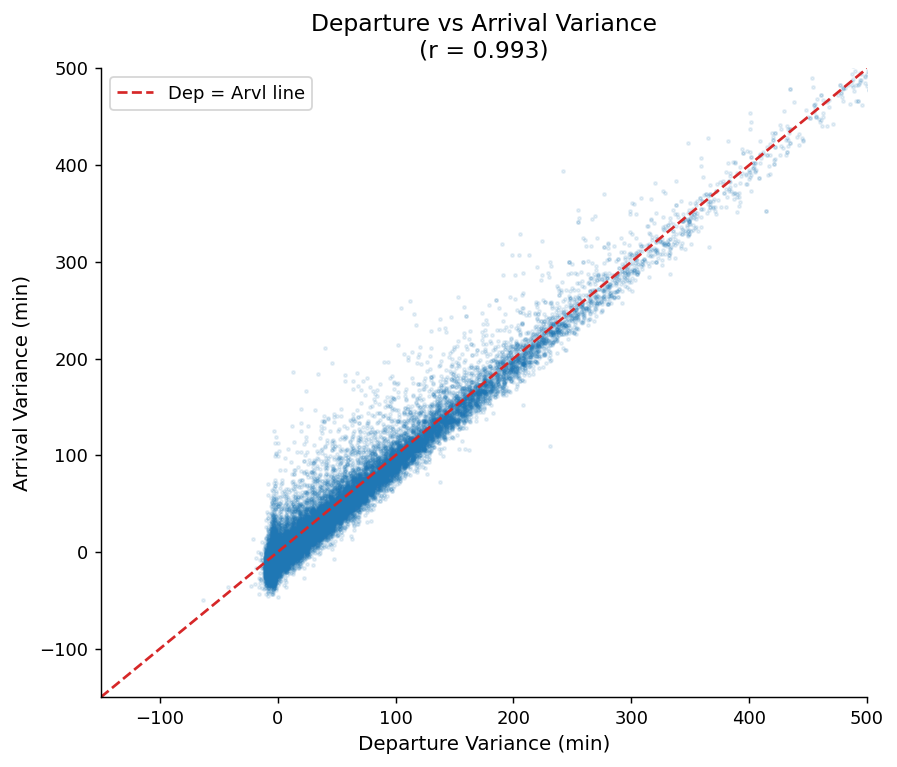

In [6]:
# ── Dep vs Arvl variance scatter (sample) ────────────────────────────────────
sample = df[[TARGET_DEP, TARGET_ARV]].dropna().sample(30_000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample[TARGET_DEP], sample[TARGET_ARV],
           alpha=0.1, s=3, color=BLUE, rasterized=True)
ax.axline((0,0), slope=1, color=RED, linewidth=1.5, linestyle='--', label='Dep = Arvl line')
ax.set_xlim(-150, 500)
ax.set_ylim(-150, 500)
ax.set_xlabel('Departure Variance (min)')
ax.set_ylabel('Arrival Variance (min)')
ax.set_title(f'Departure vs Arrival Variance\n(r = {sample[TARGET_DEP].corr(sample[TARGET_ARV]):.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('eda_comb_dep_vs_arvl.png', bbox_inches='tight')
plt.show()

---
## 3. Weather Features Analysis

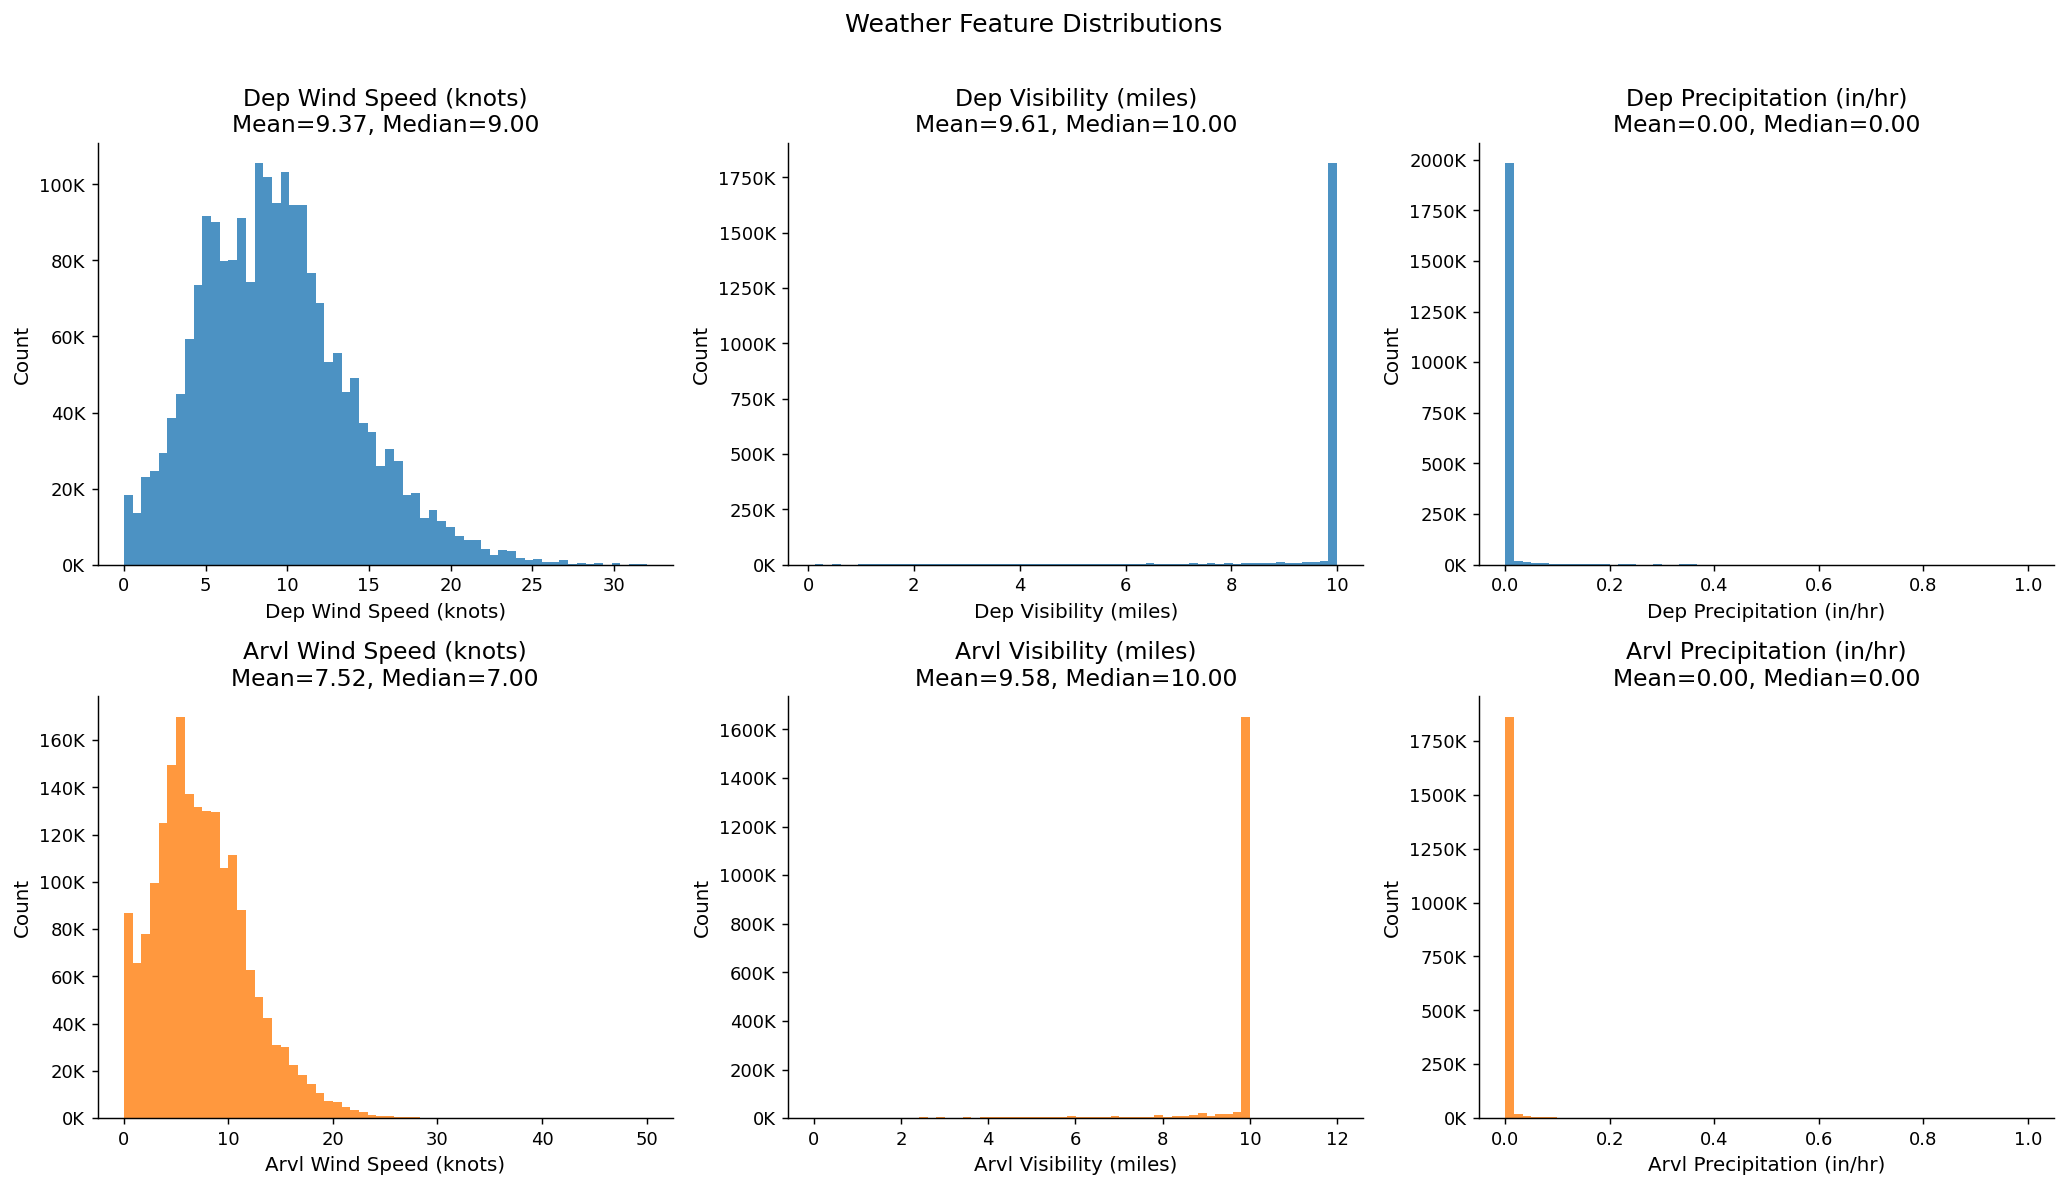

In [7]:
# ── Distributions of weather features ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

weather_info = [
    ('dep_wind_speed',   'Dep Wind Speed (knots)',   BLUE,   50),
    ('dep_visibility',   'Dep Visibility (miles)',   BLUE,   12),
    ('dep_precipitation','Dep Precipitation (in/hr)',BLUE,    1),
    ('arvl_wind_speed',  'Arvl Wind Speed (knots)',  ORANGE, 50),
    ('arvl_visibility',  'Arvl Visibility (miles)',  ORANGE, 12),
    ('arvl_precipitation','Arvl Precipitation (in/hr)',ORANGE, 1),
]

for ax, (col, label, color, clip_val) in zip(axes.flatten(), weather_info):
    data = df[col].dropna().clip(0, clip_val)
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\nMean={data.mean():.2f}, Median={data.median():.2f}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Weather Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_comb_weather_dist.png', bbox_inches='tight')
plt.show()

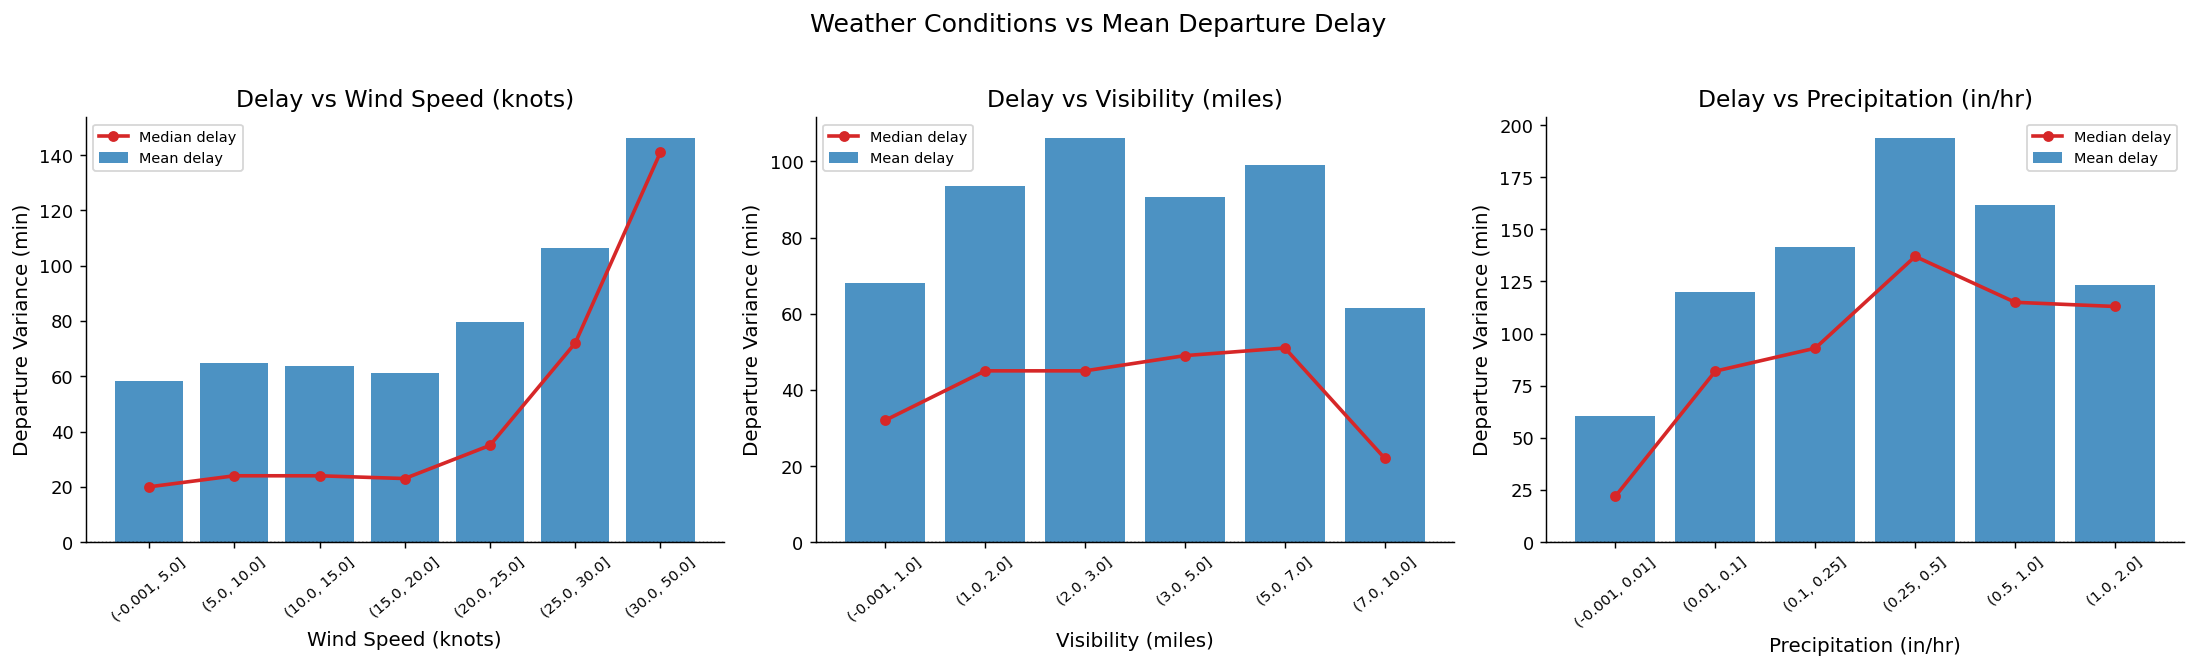

In [8]:
# ── Weather vs Departure Delay (binned scatter) ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

weather_feats = [
    ('dep_wind_speed',    'Wind Speed (knots)',    [0,5,10,15,20,25,30,50]),
    ('dep_visibility',    'Visibility (miles)',    [0,1,2,3,5,7,10,12]),
    ('dep_precipitation', 'Precipitation (in/hr)', [0,0.01,0.1,0.25,0.5,1.0,2.0]),
]

for ax, (col, xlabel, bins) in zip(axes, weather_feats):
    tmp = df[[col, TARGET_DEP]].dropna()
    tmp['bin'] = pd.cut(tmp[col], bins=bins, include_lowest=True)
    binned = tmp.groupby('bin', observed=True)[TARGET_DEP].agg(['mean', 'median', 'count'])
    
    x = range(len(binned))
    ax.bar(x, binned['mean'], color=BLUE, alpha=0.8, label='Mean delay')
    ax.plot(x, binned['median'], color=RED, marker='o', ms=5, linewidth=2, label='Median delay')
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in binned.index], rotation=40, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Departure Variance (min)')
    ax.set_title(f'Delay vs {xlabel}')
    ax.legend(fontsize=8)

plt.suptitle('Weather Conditions vs Mean Departure Delay', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_comb_weather_vs_delay.png', bbox_inches='tight')
plt.show()

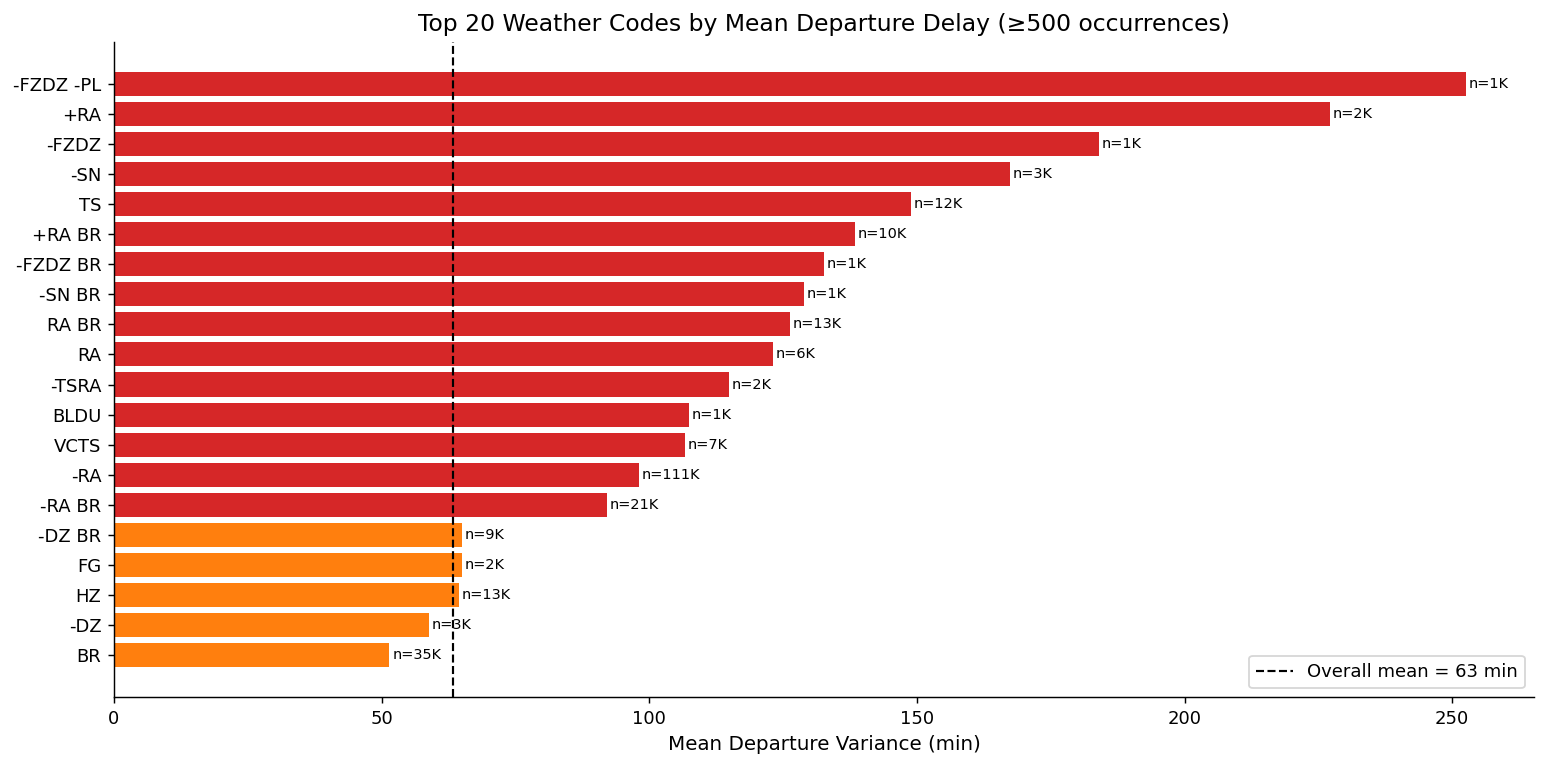

In [9]:
# ── Weather condition codes vs mean delay ────────────────────────────────────
wxcode_delay = (
    df.dropna(subset=['dep_wxcodes'])
    .groupby('dep_wxcodes')[TARGET_DEP]
    .agg(['mean', 'count'])
    .query('count >= 500')
    .sort_values('mean', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors_wx = [RED if v > 80 else ORANGE if v > 50 else BLUE for v in wxcode_delay['mean']]
ax.barh(wxcode_delay.index[::-1], wxcode_delay['mean'][::-1], color=colors_wx[::-1])
ax.axvline(df[TARGET_DEP].mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Overall mean = {df[TARGET_DEP].mean():.0f} min')
ax.set_xlabel('Mean Departure Variance (min)')
ax.set_title('Top 20 Weather Codes by Mean Departure Delay (≥500 occurrences)')
ax.legend()
for i, (val, cnt) in enumerate(zip(wxcode_delay['mean'][::-1], wxcode_delay['count'][::-1])):
    ax.text(val + 0.5, i, f'n={cnt/1e3:.0f}K', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('eda_comb_wxcode_delay.png', bbox_inches='tight')
plt.show()

Pearson Correlation with Departure Variance:


,Dep Corr w/ Dep Delay,Arvl Corr w/ Dep Delay
Feature,,
Wind Speed (knots),0.0177,-0.0113
Visibility (miles),-0.0661,-0.0434
Precipitation (in/hr),0.0838,0.0383


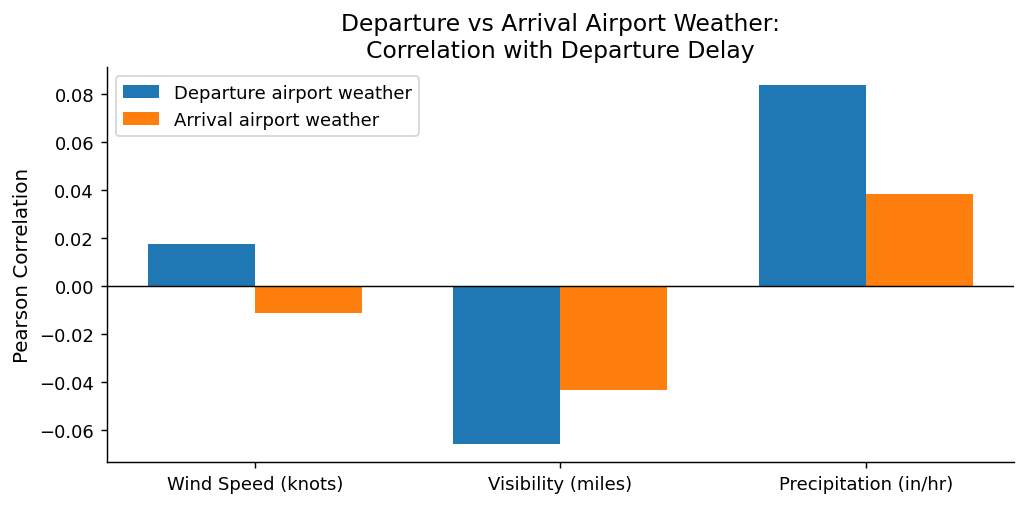

In [10]:
# ── Dep vs Arvl weather asymmetry: which matters more? ───────────────────────
weather_pairs = [
    ('dep_wind_speed',    'arvl_wind_speed',    'Wind Speed (knots)'),
    ('dep_visibility',    'arvl_visibility',    'Visibility (miles)'),
    ('dep_precipitation', 'arvl_precipitation', 'Precipitation (in/hr)'),
]

corr_rows = []
for dep_col, arvl_col, label in weather_pairs:
    corr_rows.append({
        'Feature': label,
        'Dep Corr w/ Dep Delay': df[[dep_col, TARGET_DEP]].dropna().corr().iloc[0,1],
        'Arvl Corr w/ Dep Delay': df[[arvl_col, TARGET_DEP]].dropna().corr().iloc[0,1],
    })

corr_df = pd.DataFrame(corr_rows).set_index('Feature').round(4)
print('Pearson Correlation with Departure Variance:')
display(corr_df)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(corr_df))
w = 0.35
ax.bar(x - w/2, corr_df['Dep Corr w/ Dep Delay'],  width=w, color=BLUE,   label='Departure airport weather')
ax.bar(x + w/2, corr_df['Arvl Corr w/ Dep Delay'], width=w, color=ORANGE, label='Arrival airport weather')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(corr_df.index)
ax.set_ylabel('Pearson Correlation')
ax.set_title('Departure vs Arrival Airport Weather:\nCorrelation with Departure Delay')
ax.legend()
plt.tight_layout()
plt.savefig('eda_comb_weather_asymmetry.png', bbox_inches='tight')
plt.show()

---
## 4. Airport Features vs Delay

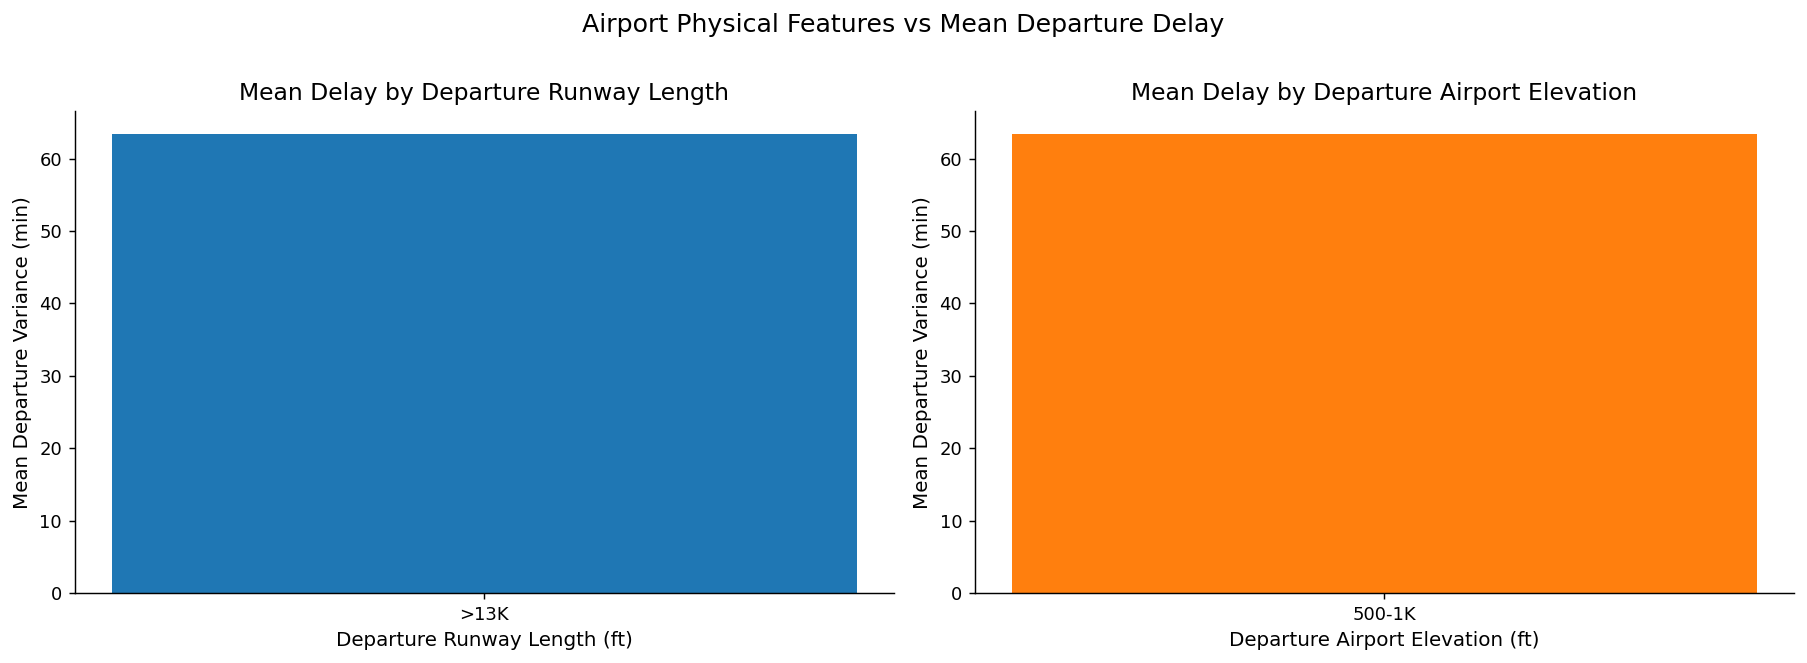

In [11]:
# ── Runway length bins vs mean delay ─────────────────────────────────────────
runway_bins   = [0, 5000, 7000, 9000, 11000, 13000, 20000]
runway_labels = ['<5K', '5-7K', '7-9K', '9-11K', '11-13K', '>13K']

df['dep_runway_bin'] = pd.cut(df['dep_LNGST_RUNWAY_FT_QTY'], bins=runway_bins, labels=runway_labels)

runway_delay = df.groupby('dep_runway_bin', observed=True)[TARGET_DEP].agg(['mean','median','count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(runway_delay.index, runway_delay['mean'], color=BLUE)
axes[0].set_xlabel('Departure Runway Length (ft)')
axes[0].set_ylabel('Mean Departure Variance (min)')
axes[0].set_title('Mean Delay by Departure Runway Length')

# Elevation bins
elev_bins   = [0, 500, 1000, 2000, 3000, 5000, 10000]
elev_labels = ['<500', '500-1K', '1-2K', '2-3K', '3-5K', '>5K']
df['dep_elev_bin'] = pd.cut(df['dep_ELEVATN_FT_QTY'], bins=elev_bins, labels=elev_labels)
elev_delay = df.groupby('dep_elev_bin', observed=True)[TARGET_DEP].agg(['mean','median','count'])

axes[1].bar(elev_delay.index, elev_delay['mean'], color=ORANGE)
axes[1].set_xlabel('Departure Airport Elevation (ft)')
axes[1].set_ylabel('Mean Departure Variance (min)')
axes[1].set_title('Mean Delay by Departure Airport Elevation')

plt.suptitle('Airport Physical Features vs Mean Departure Delay', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_comb_airport_features.png', bbox_inches='tight')
plt.show()

---
## 5. Flight Duration vs Delay

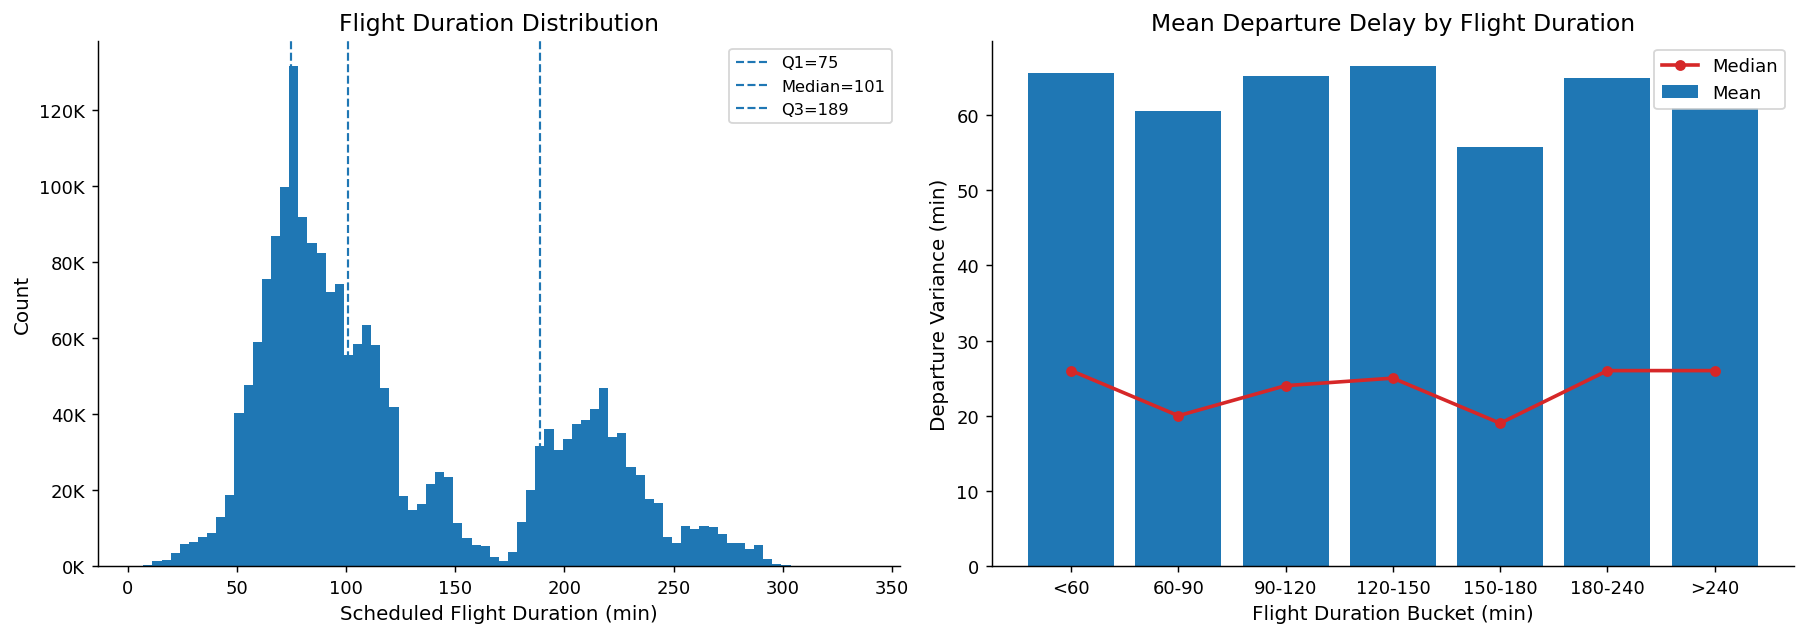

In [12]:
# ── Flight duration distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['flight_duration_min'].clip(0, 340), bins=80, color=BLUE, edgecolor='none')
axes[0].set_xlabel('Scheduled Flight Duration (min)')
axes[0].set_ylabel('Count')
axes[0].set_title('Flight Duration Distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for pct, label in [(0.25,'Q1'), (0.5,'Median'), (0.75,'Q3')]:
    val = df['flight_duration_min'].quantile(pct)
    axes[0].axvline(val, linestyle='--', linewidth=1.2, label=f'{label}={val:.0f}')
axes[0].legend(fontsize=9)

# Duration bins vs mean delay
dur_bins   = [0, 60, 90, 120, 150, 180, 240, 340]
dur_labels = ['<60', '60-90', '90-120', '120-150', '150-180', '180-240', '>240']
df['dur_bin'] = pd.cut(df['flight_duration_min'], bins=dur_bins, labels=dur_labels)
dur_delay = df.groupby('dur_bin', observed=True)[TARGET_DEP].agg(['mean','median','count'])

axes[1].bar(dur_delay.index, dur_delay['mean'], color=BLUE, label='Mean')
axes[1].plot(range(len(dur_delay)), dur_delay['median'], color=RED,
             marker='o', ms=5, linewidth=2, label='Median')
axes[1].set_xlabel('Flight Duration Bucket (min)')
axes[1].set_ylabel('Departure Variance (min)')
axes[1].set_title('Mean Departure Delay by Flight Duration')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_comb_duration.png', bbox_inches='tight')
plt.show()

---
## 6. Time Features vs Delay

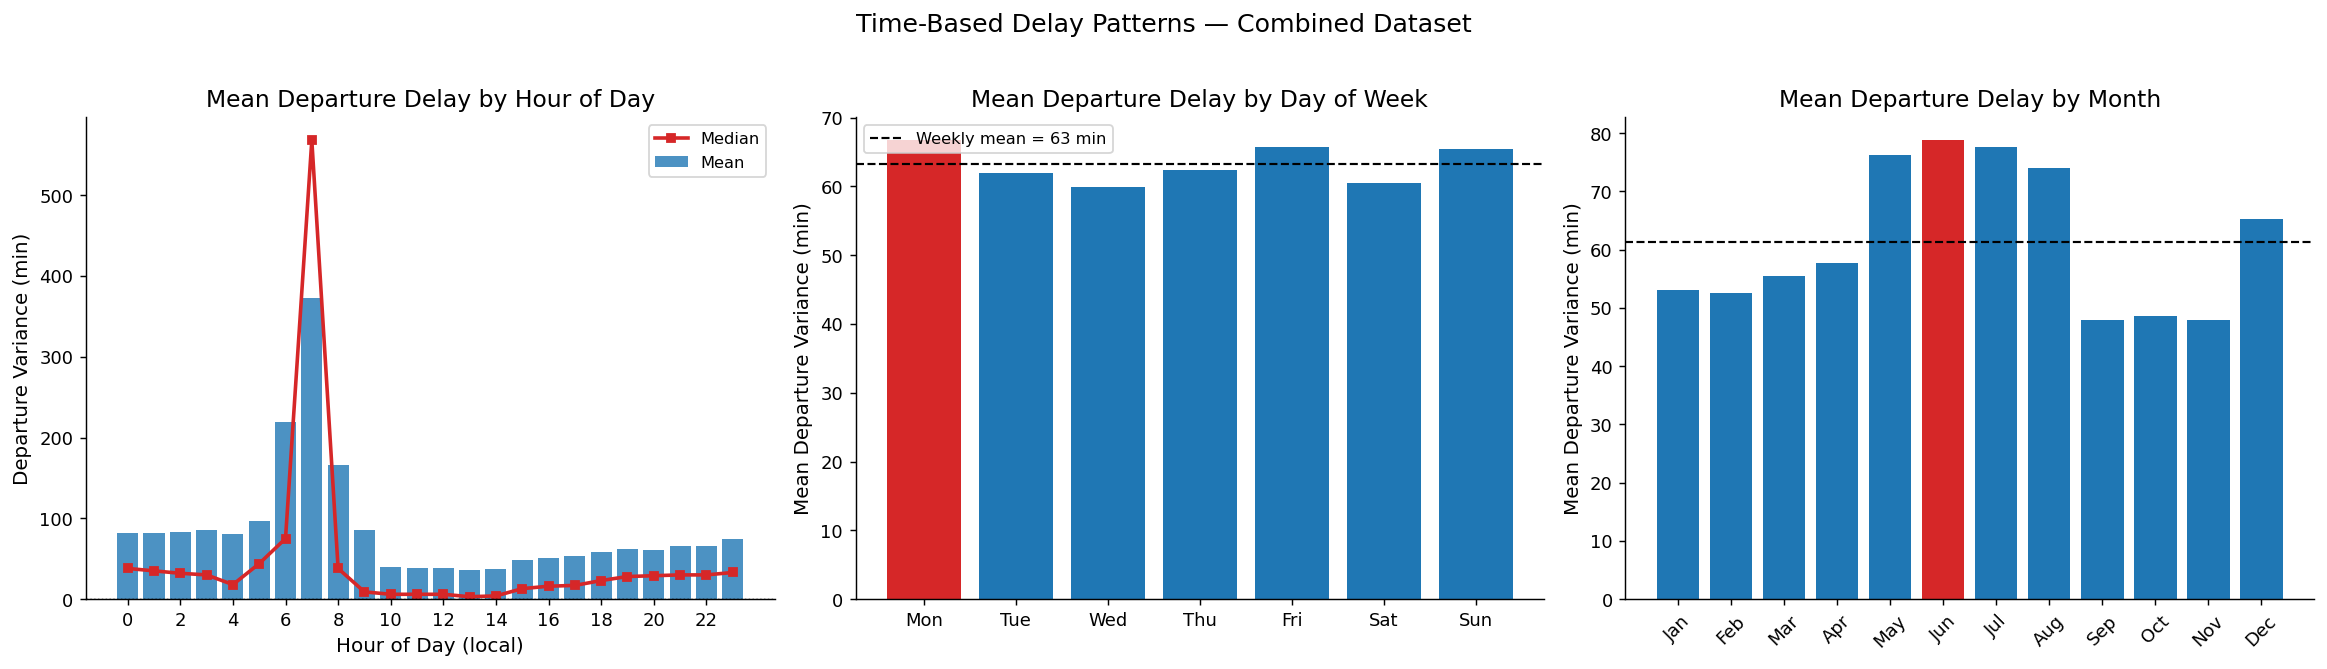

In [13]:
# ── Hour of day, day of week, month ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hour
hourly = df.groupby('dep_hour_int')[TARGET_DEP].agg(['mean','median'])
axes[0].bar(hourly.index, hourly['mean'], color=BLUE, alpha=0.8, label='Mean')
axes[0].plot(hourly.index, hourly['median'], color=RED, marker='s', ms=4, linewidth=2, label='Median')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Hour of Day (local)')
axes[0].set_ylabel('Departure Variance (min)')
axes[0].set_title('Mean Departure Delay by Hour of Day')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=9)

# Day of week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df.groupby('dep_dow')[TARGET_DEP].mean()
bar_colors = [RED if v == dow.max() else BLUE for v in dow.values]
axes[1].bar(range(7), dow.values, color=bar_colors)
axes[1].axhline(dow.mean(), color='black', linestyle='--', linewidth=1.2,
                label=f'Weekly mean = {dow.mean():.0f} min')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].set_ylabel('Mean Departure Variance (min)')
axes[1].set_title('Mean Departure Delay by Day of Week')
axes[1].legend(fontsize=9)

# Month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('dep_month')[TARGET_DEP].mean()
bar_colors_m = [RED if v == monthly.max() else BLUE for v in monthly.values]
axes[2].bar(range(1, 13), monthly.values, color=bar_colors_m)
axes[2].axhline(monthly.mean(), color='black', linestyle='--', linewidth=1.2)
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels, rotation=45)
axes[2].set_ylabel('Mean Departure Variance (min)')
axes[2].set_title('Mean Departure Delay by Month')

plt.suptitle('Time-Based Delay Patterns — Combined Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_comb_time_patterns.png', bbox_inches='tight')
plt.show()

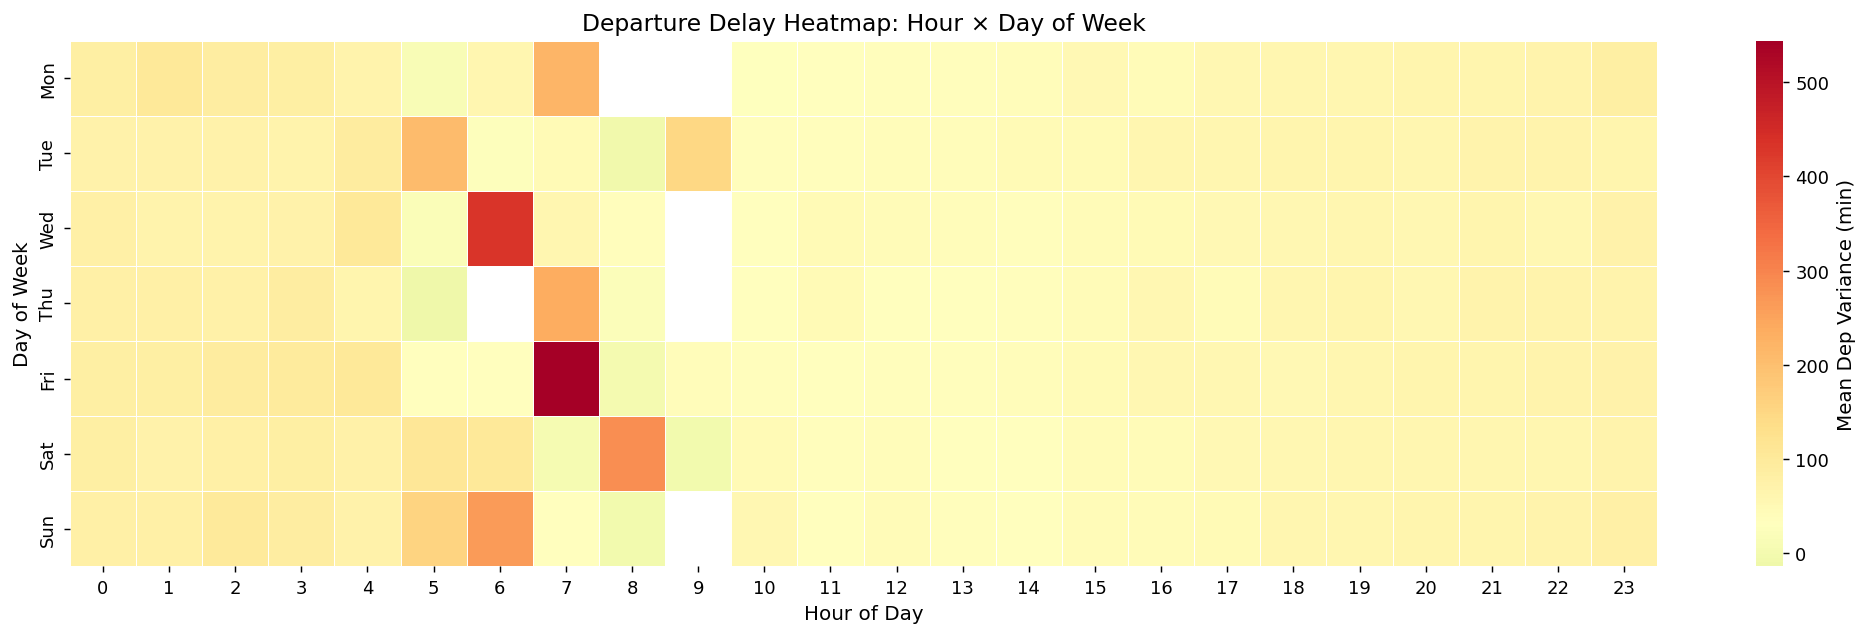

In [14]:
# ── Heatmap: hour × day-of-week mean delay ───────────────────────────────────
pivot = df.groupby(['dep_dow', 'dep_hour_int'])[TARGET_DEP].mean().unstack()
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='RdYlGn_r', center=30, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Mean Dep Variance (min)'})
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Departure Delay Heatmap: Hour × Day of Week')
plt.tight_layout()
plt.savefig('eda_comb_delay_heatmap.png', bbox_inches='tight')
plt.show()

---
## 7. ETA Update Context (POST_NBR & MINS_TO_SCHD_DEP)

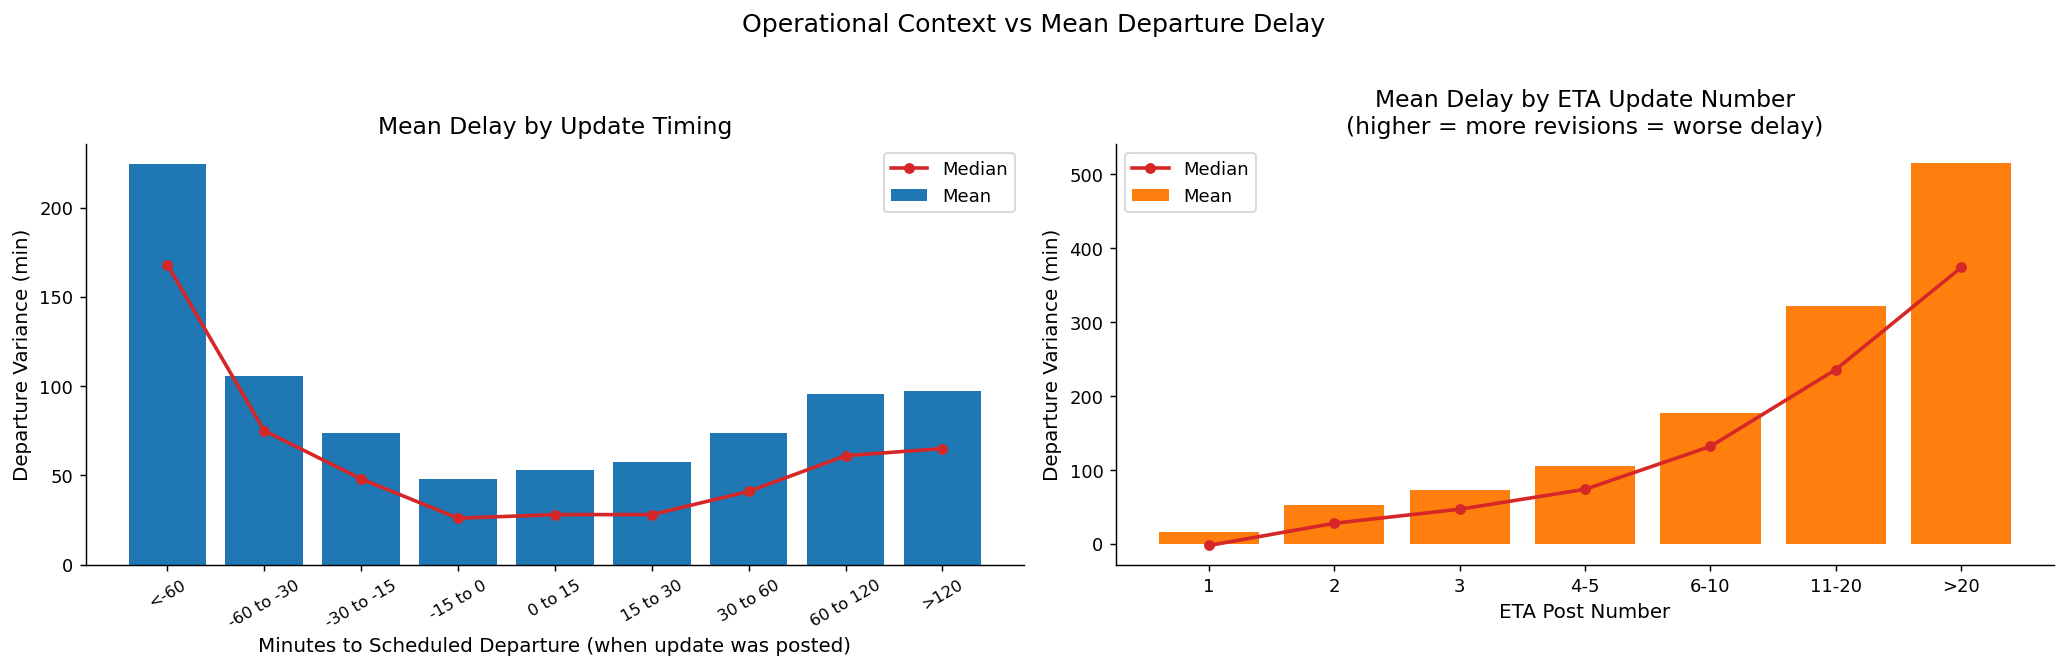

In [15]:
# ── MINS_TO_SCHD_DEP vs delay — most important operational feature ────────────
mins_bins   = [-500, -60, -30, -15, 0, 15, 30, 60, 120, 200]
mins_labels = ['<-60','-60 to -30','-30 to -15','-15 to 0','0 to 15','15 to 30','30 to 60','60 to 120','>120']
df['mins_bin'] = pd.cut(df['MINS_TO_SCHD_DEP_QTY'], bins=mins_bins, labels=mins_labels)
mins_delay = df.groupby('mins_bin', observed=True)[TARGET_DEP].agg(['mean','median','count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(mins_delay)), mins_delay['mean'], color=BLUE, label='Mean')
axes[0].plot(range(len(mins_delay)), mins_delay['median'], color=RED,
             marker='o', ms=5, linewidth=2, label='Median')
axes[0].set_xticks(range(len(mins_delay)))
axes[0].set_xticklabels(mins_delay.index, rotation=30, fontsize=9)
axes[0].set_xlabel('Minutes to Scheduled Departure (when update was posted)')
axes[0].set_ylabel('Departure Variance (min)')
axes[0].set_title('Mean Delay by Update Timing')
axes[0].legend()

# POST_NBR vs delay
post_bins   = [0,1,2,3,5,10,20,50]
post_labels = ['1','2','3','4-5','6-10','11-20','>20']
df['post_bin'] = pd.cut(df['POST_NBR'], bins=post_bins, labels=post_labels)
post_delay = df.groupby('post_bin', observed=True)[TARGET_DEP].agg(['mean','median','count'])

axes[1].bar(range(len(post_delay)), post_delay['mean'], color=ORANGE, label='Mean')
axes[1].plot(range(len(post_delay)), post_delay['median'], color=RED,
             marker='o', ms=5, linewidth=2, label='Median')
axes[1].set_xticks(range(len(post_delay)))
axes[1].set_xticklabels(post_delay.index)
axes[1].set_xlabel('ETA Post Number')
axes[1].set_ylabel('Departure Variance (min)')
axes[1].set_title('Mean Delay by ETA Update Number\n(higher = more revisions = worse delay)')
axes[1].legend()

plt.suptitle('Operational Context vs Mean Departure Delay', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_comb_operational_context.png', bbox_inches='tight')
plt.show()

---
## 8. Correlation Matrix

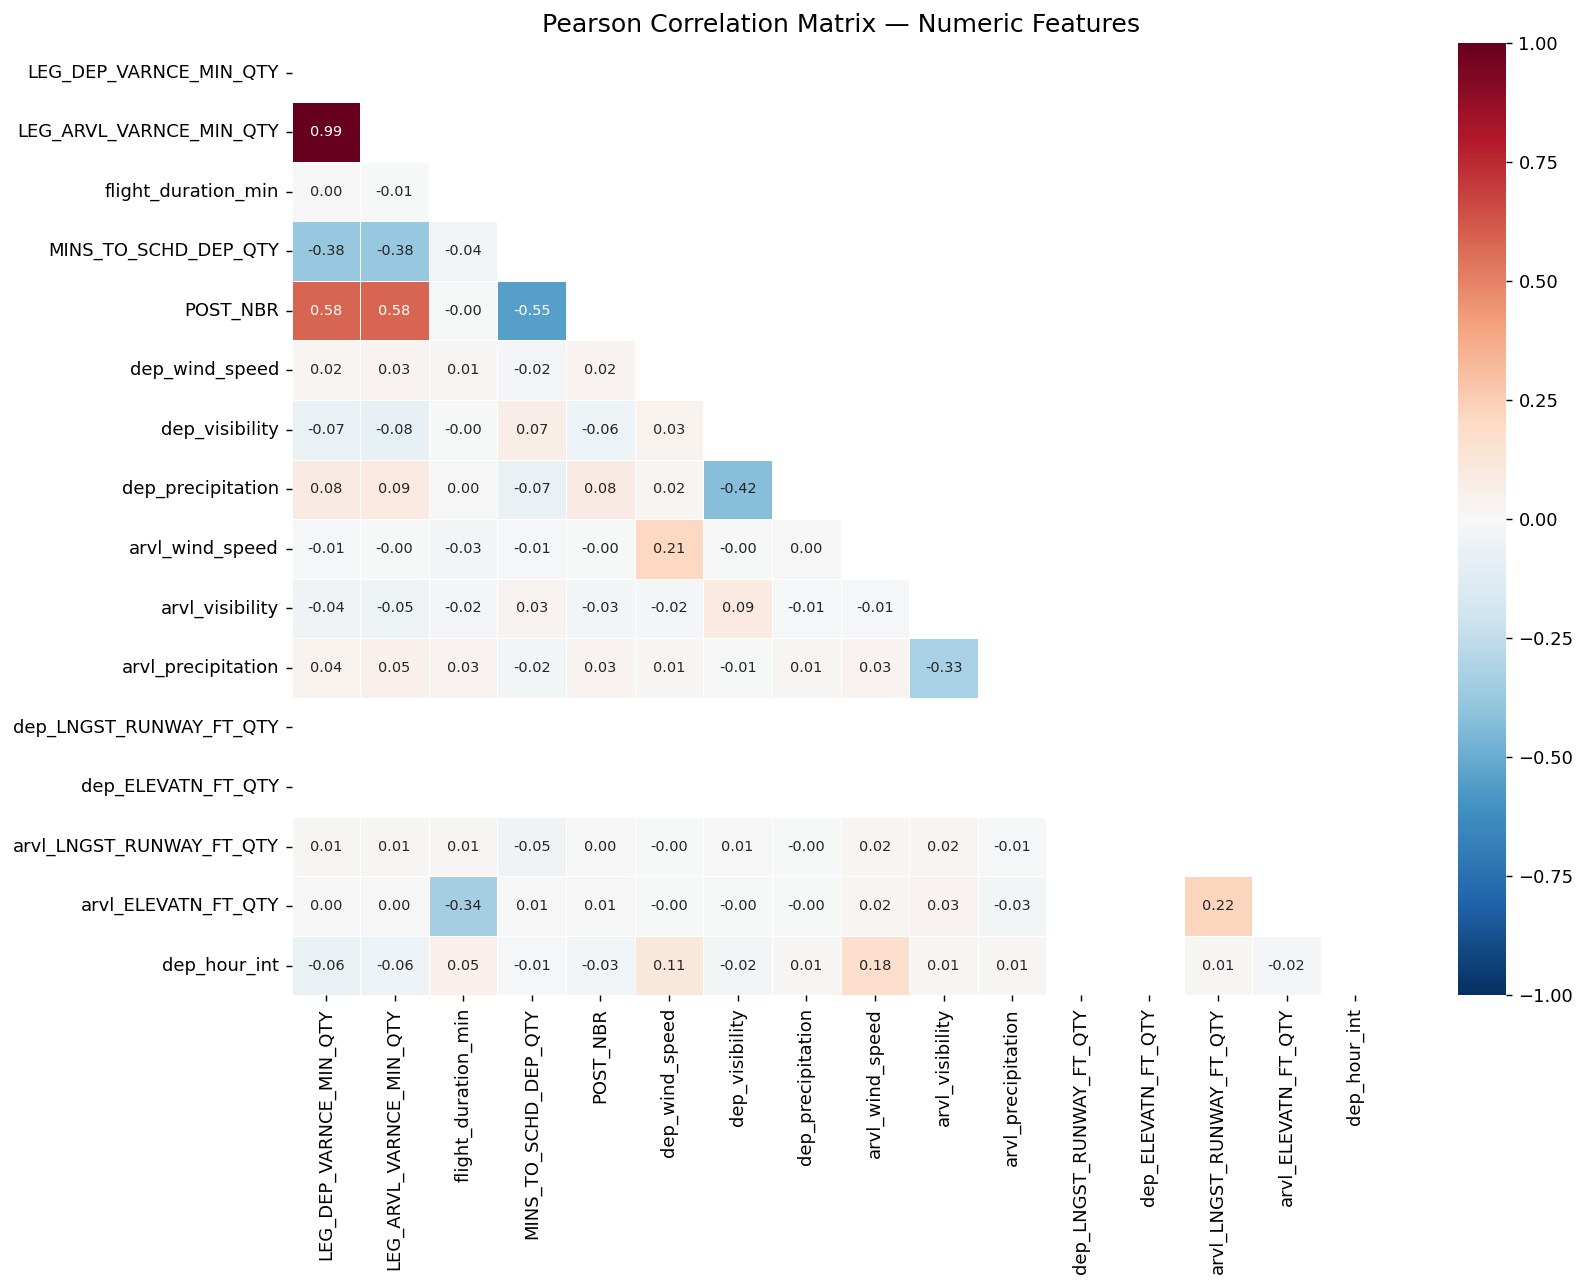

In [16]:
# ── Pearson correlation heatmap — all numeric features ────────────────────────
num_cols = [
    TARGET_DEP, TARGET_ARV,
    'flight_duration_min', 'MINS_TO_SCHD_DEP_QTY', 'POST_NBR',
    'dep_wind_speed', 'dep_visibility', 'dep_precipitation',
    'arvl_wind_speed', 'arvl_visibility', 'arvl_precipitation',
    'dep_LNGST_RUNWAY_FT_QTY', 'dep_ELEVATN_FT_QTY',
    'arvl_LNGST_RUNWAY_FT_QTY', 'arvl_ELEVATN_FT_QTY',
    'dep_hour_int',
]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix — Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('eda_comb_correlation_matrix.png', bbox_inches='tight')
plt.show()

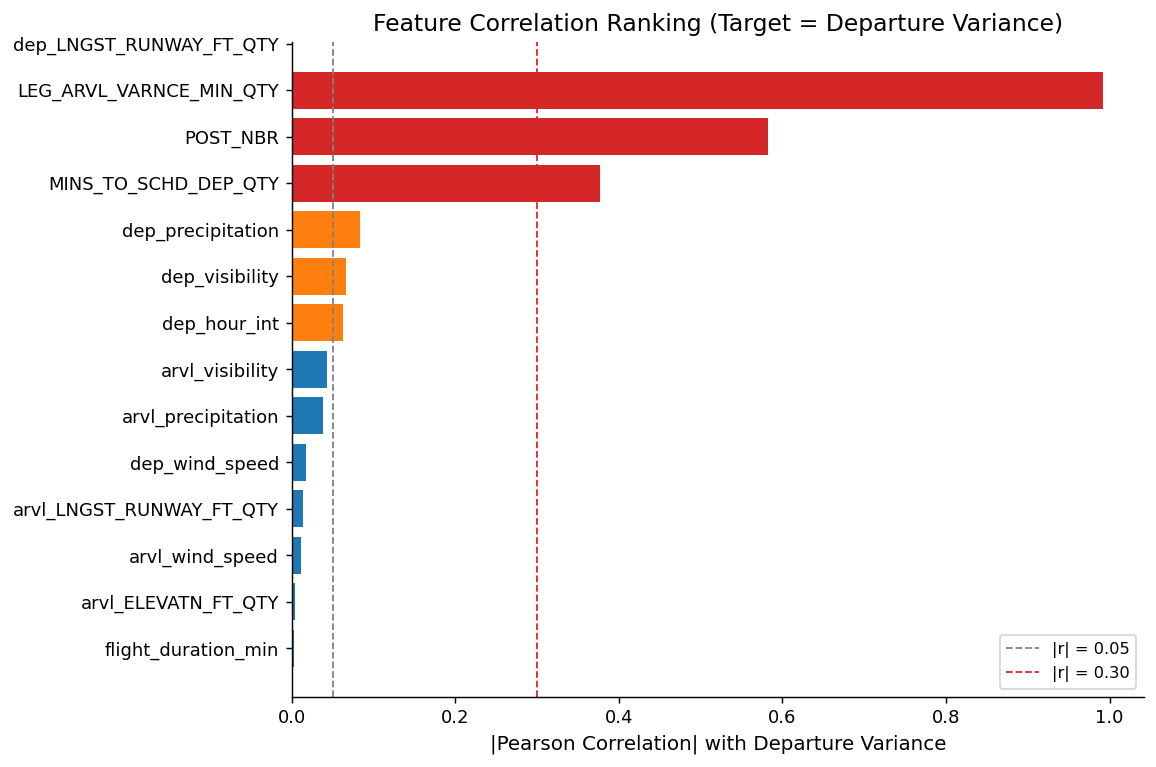

In [17]:
# ── Top features by absolute correlation with departure delay ─────────────────
target_corr = (
    corr_matrix[TARGET_DEP]
    .drop(TARGET_DEP)
    .abs()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
colors_corr = [RED if v > 0.3 else ORANGE if v > 0.05 else BLUE for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors_corr)
ax.axvline(0.05, color='gray', linestyle='--', linewidth=1, label='|r| = 0.05')
ax.axvline(0.30, color=RED,   linestyle='--', linewidth=1, label='|r| = 0.30')
ax.set_xlabel('|Pearson Correlation| with Departure Variance')
ax.set_title('Feature Correlation Ranking (Target = Departure Variance)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('eda_comb_feature_correlation.png', bbox_inches='tight')
plt.show()

---
## 9. Airline & Delay Reason (Combined View)

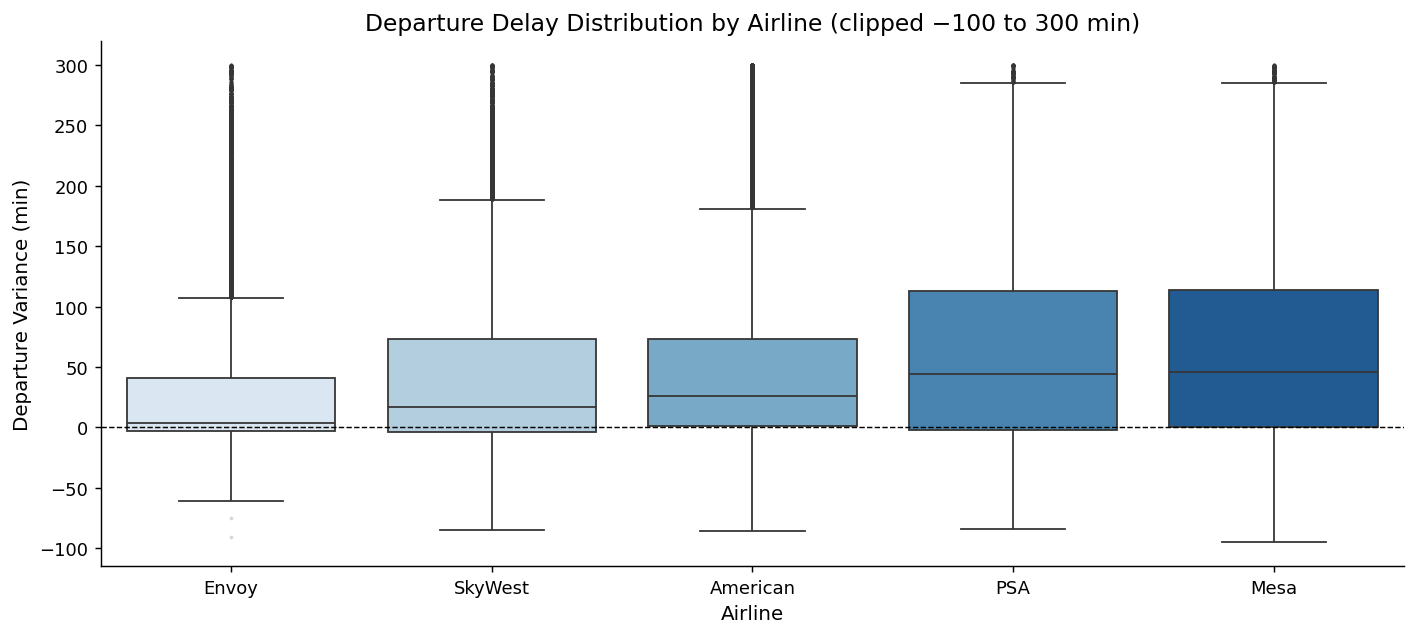

In [18]:
# ── Delay distribution by airline (box plot) ─────────────────────────────────
airline_map = {'AA':'American','MQ':'Envoy','OO':'SkyWest','YV':'Mesa','OH':'PSA'}
df['airline_label'] = df['OPERAT_AIRLN_IATA_CD'].map(airline_map).fillna(df['OPERAT_AIRLN_IATA_CD'])

fig, ax = plt.subplots(figsize=(11, 5))
order = df.groupby('airline_label')[TARGET_DEP].median().sort_values().index
sample_box = df[df[TARGET_DEP].between(-100, 300)]
sns.boxplot(data=sample_box, x='airline_label', y=TARGET_DEP,
            order=order, palette='Blues', ax=ax,
            flierprops={'marker':'o','markersize':1,'alpha':0.2})
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Airline')
ax.set_ylabel('Departure Variance (min)')
ax.set_title('Departure Delay Distribution by Airline (clipped −100 to 300 min)')
plt.tight_layout()
plt.savefig('eda_comb_airline_boxplot.png', bbox_inches='tight')
plt.show()

,Mean (min),Median (min),Count
No reason code (on-time / minor),16.3,-2.0,"1,019,075"
Has delay reason code,109.2,64.0,"1,043,788"


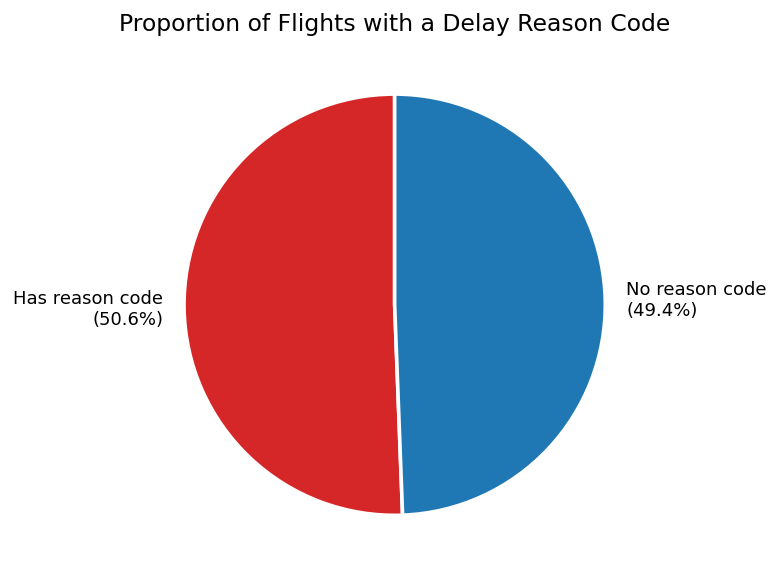

In [19]:
# ── Delay reason presence vs mean delay ──────────────────────────────────────
df['has_delay_reason'] = df['FLIFO_DELAY_REASON_CD'].notna()

reason_split = df.groupby('has_delay_reason')[TARGET_DEP].agg(['mean','median','count'])
reason_split.index = ['No reason code (on-time / minor)', 'Has delay reason code']
reason_split.columns = ['Mean (min)', 'Median (min)', 'Count']
reason_split['Count'] = reason_split['Count'].map('{:,}'.format)
display(reason_split.round(1))

# Pie: proportion with/without reason
fig, ax = plt.subplots(figsize=(6, 6))
sizes = [df['has_delay_reason'].sum(), (~df['has_delay_reason']).sum()]
labels = [f'Has reason code\n({sizes[0]/len(df)*100:.1f}%)',
          f'No reason code\n({sizes[1]/len(df)*100:.1f}%)']
ax.pie(sizes, labels=labels, colors=[RED, BLUE], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Proportion of Flights with a Delay Reason Code')
plt.tight_layout()
plt.savefig('eda_comb_reason_pie.png', bbox_inches='tight')
plt.show()

---
## 10. Modeling Dataset Coverage Check

In [20]:
# ── How much data survived into the modeling dataset? ────────────────────────
modeling_rows = 211_800
combined_rows = len(df)

print(f'Combined dataset   : {combined_rows:>10,} rows (100%)')
print(f'Modeling dataset   : {modeling_rows:>10,} rows ({modeling_rows/combined_rows*100:.1f}%)')
print(f'Dropped in feat eng: {combined_rows - modeling_rows:>10,} rows ({(combined_rows - modeling_rows)/combined_rows*100:.1f}%)')
print()
print('Primary reasons for row reduction in feature engineering:')
print('  - Removed rows with no weather data at departure airport')
print('  - Removed extreme outlier variance values')
print('  - Filtered to T-30 min snapshot window (single post per flight)')

Combined dataset   :  2,062,951 rows (100%)
Modeling dataset   :    211,800 rows (10.3%)
Dropped in feat eng:  1,851,151 rows (89.7%)

Primary reasons for row reduction in feature engineering:
  - Removed rows with no weather data at departure airport
  - Removed extreme outlier variance values
  - Filtered to T-30 min snapshot window (single post per flight)


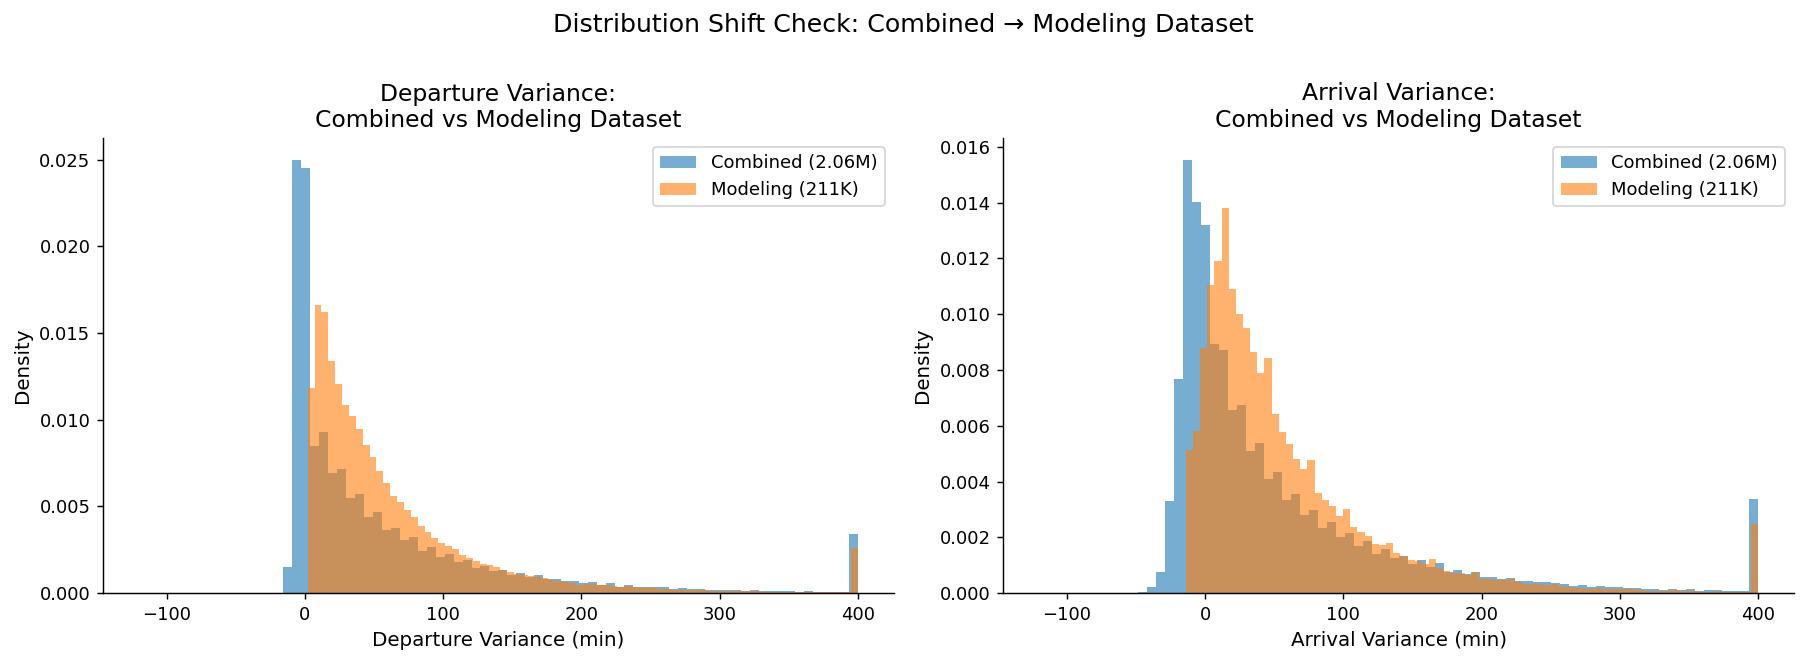

In [21]:
# ── Sanity check: combined vs modeling target distributions ──────────────────
modeling_df = pd.read_csv('modeling_dataset.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['LEG_DEP_VARNCE_MIN_QTY', 'LEG_ARVL_VARNCE_MIN_QTY'],
    ['Departure Variance', 'Arrival Variance']
):
    ax.hist(df[col].dropna().clip(-120, 400),       bins=80, alpha=0.6, color=BLUE,   label='Combined (2.06M)', density=True)
    ax.hist(modeling_df[col].clip(-120, 400),        bins=80, alpha=0.6, color=ORANGE, label='Modeling (211K)',  density=True)
    ax.set_xlabel(f'{title} (min)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}:\nCombined vs Modeling Dataset')
    ax.legend()

plt.suptitle('Distribution Shift Check: Combined → Modeling Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_comb_vs_modeling_dist.png', bbox_inches='tight')
plt.show()